# Melanoma Classification - Exploratory Data Analysis (EDA)
This notebook:
1. Checks if all images from the CSV are available on disk
2. Shows the class distribution (class imbalance)
3. Analyzes metadata (age, sex, body site)
4. Displays sample images

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 1. Load CSV & first look

In [2]:
df = pd.read_csv('data/train.csv')
print(f'Total samples: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Total samples: 33126
Columns: ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


## 2. Check: Are all images from the CSV available on disk?

In [3]:
IMAGE_DIR = 'data/train/'

# All images on disk - strip extension, supports both .jpg and .png
available_images = set(
    os.path.splitext(f)[0]
    for f in os.listdir(IMAGE_DIR)
    if f.endswith('.jpg') or f.endswith('.png')
)

expected_images = set(df['image_name'].values)
missing = expected_images - available_images
extra   = available_images - expected_images

print(f'Images on disk:           {len(available_images)}')
print(f'Images in CSV:            {len(expected_images)}')
print(f'Missing images:           {len(missing)}')
print(f'Images without CSV entry: {len(extra)}')

if len(missing) == 0:
    print('\n All images found!')
else:
    print(f'\n {len(missing)} images missing!')
    print(list(missing)[:5])

# Detect image format (.jpg or .png)
sample_file = os.listdir(IMAGE_DIR)[0]
IMG_EXT = os.path.splitext(sample_file)[1]
print(f'\nImage format detected: {IMG_EXT}')

Images on disk:           33126
Images in CSV:            33126
Missing images:           0
Images without CSV entry: 0

 All images found!

Image format detected: .png


## 3. Class Distribution (Class Imbalance)

Benign:   32542 (98.2%)
Melanoma: 584 (1.8%)


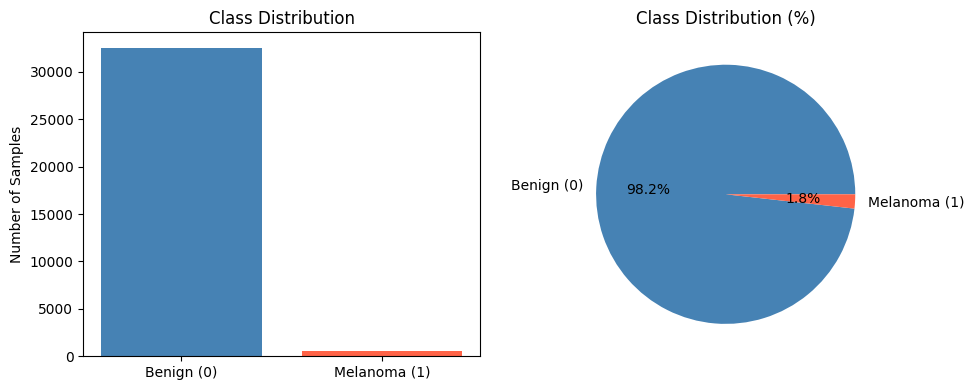

In [4]:
counts = df['target'].value_counts()
print(f'Benign:   {counts[0]} ({counts[0]/len(df):.1%})')
print(f'Melanoma: {counts[1]} ({counts[1]/len(df):.1%})')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Benign (0)', 'Melanoma (1)']
axes[0].bar(labels, [counts[0], counts[1]], color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Samples')
axes[1].pie([counts[0], counts[1]], labels=labels, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.show()

## 4. Metadata Analysis

In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
image_name                         0
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64


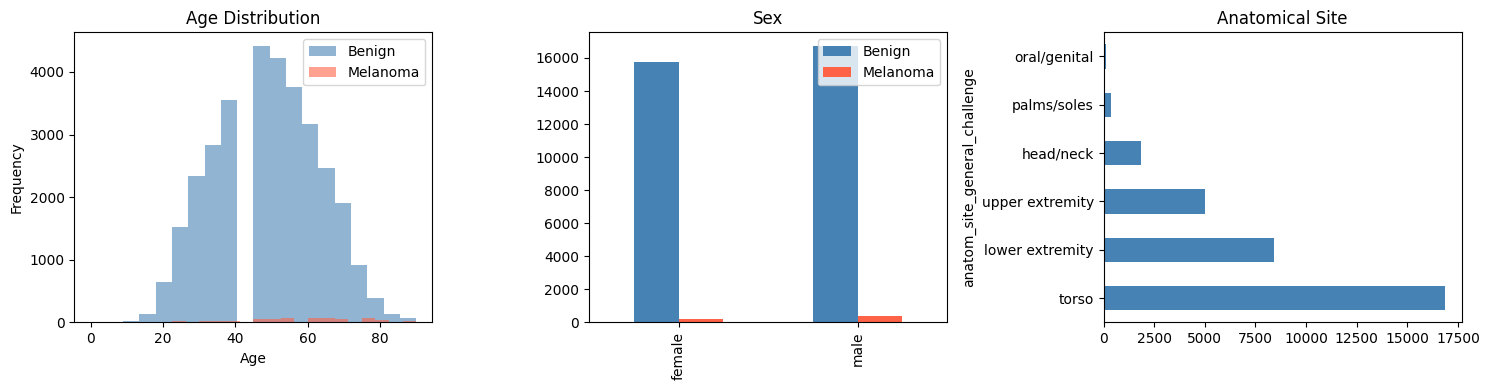

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for target, color, label in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Melanoma')]:
    df[df['target'] == target]['age_approx'].plot(
        kind='hist', bins=20, alpha=0.6, ax=axes[0], color=color, label=label
    )
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

df.groupby(['sex', 'target']).size().unstack().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato']
)
axes[1].set_title('Sex')
axes[1].set_xlabel('')
axes[1].legend(['Benign', 'Melanoma'])

df['anatom_site_general_challenge'].value_counts().head(8).plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Anatomical Site')

plt.tight_layout()
plt.show()

## 5. Sample Images

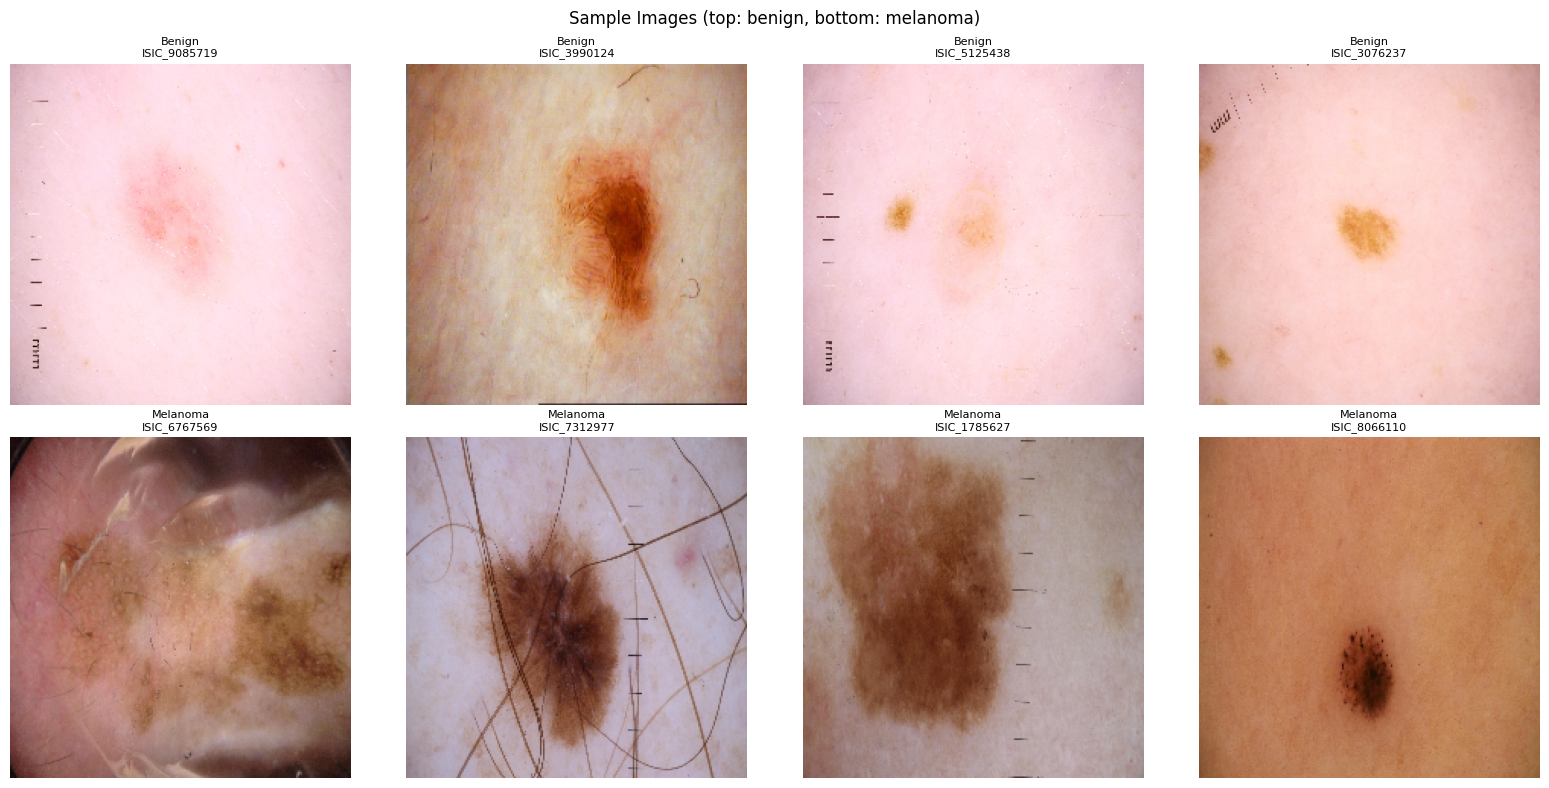

In [7]:
benign    = df[df['target'] == 0].sample(4, random_state=42)
malignant = df[df['target'] == 1].sample(4, random_state=42)
samples   = pd.concat([benign, malignant])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    img_path = os.path.join(IMAGE_DIR, row['image_name'] + IMG_EXT)
    img = Image.open(img_path)
    axes[i].imshow(img)
    label = 'Melanoma' if row['target'] == 1 else 'Benign'
    axes[i].set_title(f"{label}\n{row['image_name']}", fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Images (top: benign, bottom: melanoma)', fontsize=12)
plt.tight_layout()
plt.show()